# Searching for Protons in Intermediate-Energy Events

**Setup.** The classifier from the previous notebook was trained on shape features (`mu`, `log sigma`, `log tau`) of *known* alpha (high-energy, class 2) and beta (low-energy, class 1) events. This notebook applies it — and a class-conditional OOD detector — to a separate sample of **93 intermediate-energy events** (all labeled class 3 in the file, meaning they sit in the energy gap between the alpha and beta thresholds). The question is whether any of these 93 events belong to a third population (protons), or whether they're just alpha and beta tails that happen to fall in the intermediate-energy window.

**What we expect.**
- If the test events are just alpha/beta tails, they should look like alphas or betas in shape space, and the OOD detector should fire only on a few stragglers.
- If there's a third population, we should see (a) events that the classifier handles with low confidence, (b) elevated OOD rates, (c) a coherent shift in the shape-feature distributions relative to training, and (d) unsupervised model selection (e.g., GMM BIC) preferring more than 2 components on the test set.

## 1. Load training and test data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import mahalanobis
from scipy.stats import ks_2samp

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import IsolationForest
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.cluster import KMeans

RNG = 42
np.random.seed(RNG)
sns.set_theme(style='ticks', context='notebook')

COL_NAMES = ['Entry', 'Class', 'Occurrence', 'Energy', 'C', 'A', 'mu', 'sigma', 'tau', 'rise_rate']

def load(path):
    df = pd.read_csv(path, sep=r'\s+', header=None, names=COL_NAMES)
    df['log_sigma'] = np.log10(df['sigma'])
    df['log_tau'] = np.log10(df['tau'])
    return df

train = load('traceDataMoreTrainEntries.txt')
test = load('traceDataMoreTestEntries.txt')

SHAPE = ['mu', 'log_sigma', 'log_tau']
LABELS = {'mu': r'$\mu$ (time)', 'log_sigma': r'$\log_{10}\sigma$', 'log_tau': r'$\log_{10}\tau$'}

print(f'Training: {len(train)} events, classes {sorted(train.Class.unique())}')
print(f'Test:     {len(test)} events, classes {sorted(test.Class.unique())}')
print(f'\nEnergy ranges:')
print(f'  Train beta  (class 1): {train[train.Class==1].Energy.min():.0f} – {train[train.Class==1].Energy.max():.0f}')
print(f'  Train alpha (class 2): {train[train.Class==2].Energy.min():.0f} – {train[train.Class==2].Energy.max():.0f}')
print(f'  Test  intermediate:    {test.Energy.min():.0f} – {test.Energy.max():.0f}')

Training: 594 events, classes [np.int64(1), np.int64(2)]
Test:     93 events, classes [np.int64(3)]

Energy ranges:
  Train beta  (class 1): 0 – 489
  Train alpha (class 2): 1537 – 20692
  Test  intermediate:    504 – 1497


The test events sit cleanly in the energy gap (504–1497) between the training beta maximum (489) and alpha minimum (1537), as expected.

## 2. Train the classifier on all training data

We retrain on the full training set this time (no held-out split) because we have a separate test file to evaluate on. Logistic regression with shape features gave ~100% CV accuracy in the previous notebook, so we'll use it again.

In [2]:
X_train = train[SHAPE].values
y_train = train['Class'].values
X_test = test[SHAPE].values

scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

clf = LogisticRegression(max_iter=1000, random_state=RNG, C=1.0).fit(X_train_s, y_train)

# Cross-validation sanity check
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG)
gs = GridSearchCV(Pipeline([('scale', StandardScaler()),
                            ('clf', LogisticRegression(max_iter=1000, random_state=RNG))]),
                  {'clf__C': [0.1, 1.0, 10.0]}, cv=cv, scoring='balanced_accuracy', n_jobs=-1)
gs.fit(X_train, y_train)
print(f'5-fold CV balanced accuracy on training: {gs.best_score_:.4f}')

5-fold CV balanced accuracy on training: 1.0000


## 3. Apply the classifier to the intermediate-energy test events

In [3]:
y_test_pred = clf.predict(X_test_s)
y_test_proba = clf.predict_proba(X_test_s)
max_proba = y_test_proba.max(axis=1)

print(f'Classifier predictions on {len(test)} intermediate-energy events:')
print(f'  Predicted beta  (1): {(y_test_pred == 1).sum()}')
print(f'  Predicted alpha (2): {(y_test_pred == 2).sum()}')

print(f'\nClassifier confidence:')
print(f'  Mean max-probability: {max_proba.mean():.3f}')
print(f'  Median:               {np.median(max_proba):.3f}')
print(f'  Min:                  {max_proba.min():.3f}')
print(f'  Events with max prob < 0.9: {(max_proba < 0.9).sum()} ({100*(max_proba < 0.9).mean():.0f}%)')
print(f'  Events with max prob < 0.7: {(max_proba < 0.7).sum()} ({100*(max_proba < 0.7).mean():.0f}%)')

Classifier predictions on 93 intermediate-energy events:
  Predicted beta  (1): 50
  Predicted alpha (2): 43

Classifier confidence:
  Mean max-probability: 0.806
  Median:               0.846
  Min:                  0.510
  Events with max prob < 0.9: 56 (60%)
  Events with max prob < 0.7: 28 (30%)


**Already a red flag.** On training data the classifier was ~100% confident (max probability near 1.0 for almost every event). On the test set, mean max-probability is 0.81 and 60% of events have max-probability below 0.9 — meaning the classifier is genuinely uncertain about most of these events. This is the kind of confidence drop you'd expect when applying a binary model to data that contains a third class.

## 4. Where are the test events in shape space?

The most direct way to see what's going on is to overlay the test events on the training distribution.

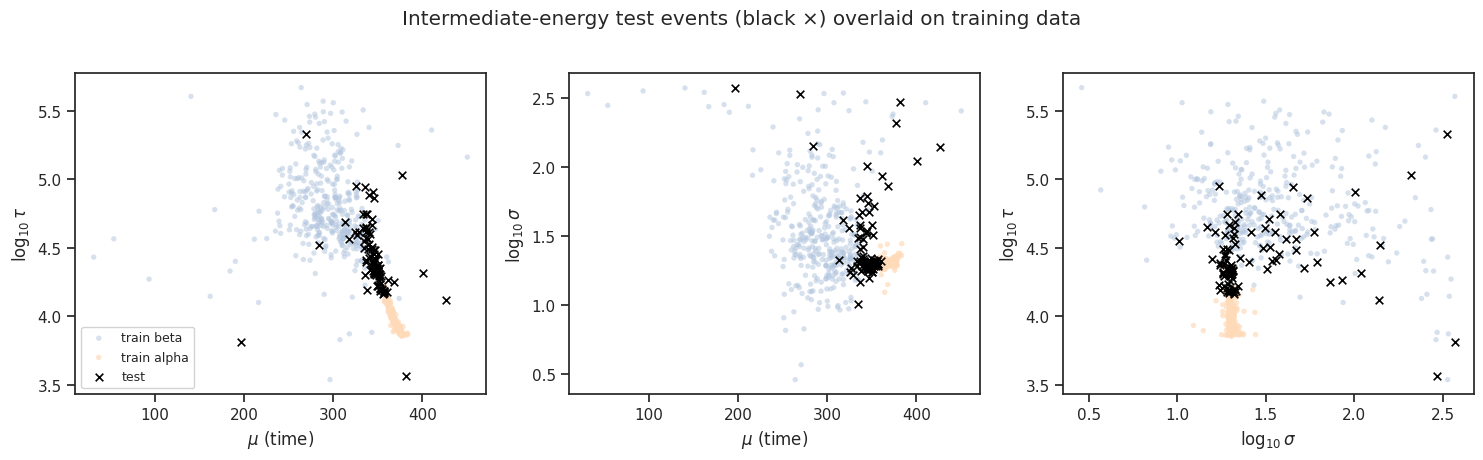

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
pair_specs = [('mu', 'log_tau'), ('mu', 'log_sigma'), ('log_sigma', 'log_tau')]

for ax, (fx, fy) in zip(axes, pair_specs):
    ax.scatter(train[train.Class==1][fx], train[train.Class==1][fy],
               c='lightsteelblue', s=15, alpha=0.5, label='train beta', edgecolors='none')
    ax.scatter(train[train.Class==2][fx], train[train.Class==2][fy],
               c='peachpuff', s=15, alpha=0.7, label='train alpha', edgecolors='none')
    ax.scatter(test[fx], test[fy], c='black', marker='x', s=30, label='test', linewidths=1.2)
    ax.set_xlabel(LABELS[fx]); ax.set_ylabel(LABELS[fy])

axes[0].legend(loc='best', fontsize=9, framealpha=0.85)
fig.suptitle('Intermediate-energy test events (black ×) overlaid on training data', y=1.02)
plt.tight_layout()
plt.show()

**Striking observation.** The bulk of the test events (the dense black cluster) sit just *above* and slightly to the left of the training alpha cluster in the (mu, log tau) plane. They are not in the training alpha region, and they are not in the training beta region — they form their own compact group between the two. A handful of outliers sit far from both clusters in the high-sigma, high-tau regions of the third panel.

## 5. Quantifying the shift: are test "predicted alphas" really alphas?

The classifier called 43 events "alpha" and 50 "beta." If these are genuine alphas and betas with intermediate energies, their shape distributions should match the training distributions. Let's test this with KS tests.

In [5]:
print('=== Distribution tests: test predicted-alpha vs training alpha ===')
for feat in SHAPE:
    a = train[train.Class==2][feat].values
    b = test[y_test_pred==2][feat].values
    ks = ks_2samp(a, b)
    print(f'  {feat:10s}: KS statistic = {ks.statistic:.3f}, p = {ks.pvalue:.2e}')

print('\n=== Distribution tests: test predicted-beta vs training beta ===')
for feat in SHAPE:
    a = train[train.Class==1][feat].values
    b = test[y_test_pred==1][feat].values
    ks = ks_2samp(a, b)
    print(f'  {feat:10s}: KS statistic = {ks.statistic:.3f}, p = {ks.pvalue:.2e}')

=== Distribution tests: test predicted-alpha vs training alpha ===
  mu        : KS statistic = 0.881, p = 2.09e-31
  log_sigma : KS statistic = 0.325, p = 6.37e-04
  log_tau   : KS statistic = 0.901, p = 1.53e-33

=== Distribution tests: test predicted-beta vs training beta ===
  mu        : KS statistic = 0.768, p = 6.15e-27
  log_sigma : KS statistic = 0.137, p = 3.47e-01
  log_tau   : KS statistic = 0.403, p = 5.95e-07


**The "predicted alphas" are decisively not from the training-alpha distribution.** All three shape features differ significantly (p < 0.001), with p-values for `mu` and `log_tau` essentially zero (< 10⁻³¹). The "predicted betas" are also shifted, but more mildly — `log_sigma` matches the training betas well (p = 0.35).

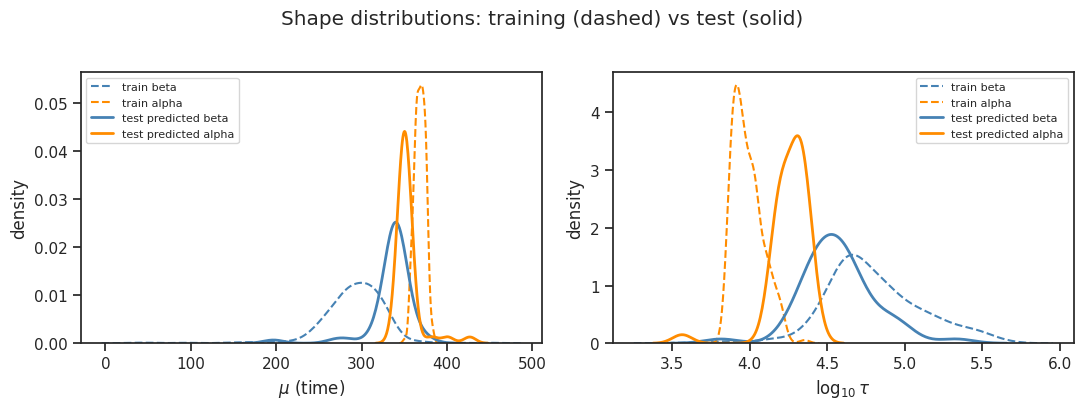

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for feat, ax in zip(['mu', 'log_tau'], axes):
    sns.kdeplot(train[train.Class==1][feat], ax=ax, color='steelblue', linestyle='--',
                label='train beta', linewidth=1.5)
    sns.kdeplot(train[train.Class==2][feat], ax=ax, color='darkorange', linestyle='--',
                label='train alpha', linewidth=1.5)
    sns.kdeplot(test[y_test_pred==1][feat], ax=ax, color='steelblue', linestyle='-',
                label='test predicted beta', linewidth=2)
    sns.kdeplot(test[y_test_pred==2][feat], ax=ax, color='darkorange', linestyle='-',
                label='test predicted alpha', linewidth=2)
    ax.set_xlabel(LABELS[feat]); ax.set_ylabel('density'); ax.legend(fontsize=8)
fig.suptitle('Shape distributions: training (dashed) vs test (solid)', y=1.02)
plt.tight_layout()
plt.show()

The `log_tau` panel is the clearest evidence. The test "predicted alpha" peak (solid orange) is offset from the training alpha peak (dashed orange) by ~0.3 dex — a factor of 2 in tau. The test "predicted beta" distribution (solid blue) sits inside the training beta distribution but shifted toward shorter tau. *Something* with intermediate decay constants is showing up in the test set that isn't present in either training class.

## 6. Mahalanobis distance to training cluster centers

Another way to quantify "how far from the training distribution is each test event": compute the Mahalanobis distance from each test event to the center of its predicted class. This is scale-invariant and accounts for the shape of the cluster.

In [7]:
def mahalanobis_to_class(X_s, cls_label, X_train_s, y_train):
    mask = y_train == cls_label
    mu = X_train_s[mask].mean(axis=0)
    cov = np.cov(X_train_s[mask].T)
    inv_cov = np.linalg.inv(cov)
    return np.array([mahalanobis(x, mu, inv_cov) for x in X_s])

# Distances within training (for context)
d_train_alpha = mahalanobis_to_class(X_train_s[y_train==2], 2, X_train_s, y_train)
d_train_beta  = mahalanobis_to_class(X_train_s[y_train==1], 1, X_train_s, y_train)

# Distances for test events, each to its predicted-class center
d_test_alpha = mahalanobis_to_class(X_test_s[y_test_pred==2], 2, X_train_s, y_train)
d_test_beta  = mahalanobis_to_class(X_test_s[y_test_pred==1], 1, X_train_s, y_train)

print('Mahalanobis distance to predicted-class center:')
print(f'                       median   95%      max')
print(f'  train alphas:       {np.median(d_train_alpha):>6.2f}  {np.percentile(d_train_alpha,95):>6.2f}  {d_train_alpha.max():>6.2f}')
print(f'  test predicted-alpha:{np.median(d_test_alpha):>6.2f}  {np.percentile(d_test_alpha,95):>6.2f}  {d_test_alpha.max():>6.2f}')
print(f'  train betas:        {np.median(d_train_beta):>6.2f}  {np.percentile(d_train_beta,95):>6.2f}  {d_train_beta.max():>6.2f}')
print(f'  test predicted-beta:{np.median(d_test_beta):>6.2f}  {np.percentile(d_test_beta,95):>6.2f}  {d_test_beta.max():>6.2f}')

Mahalanobis distance to predicted-class center:
                       median   95%      max
  train alphas:         1.25    3.09    7.23
  test predicted-alpha:  3.82   26.27   49.52
  train betas:          1.24    3.08    6.98
  test predicted-beta:  1.65    3.21    4.45


**Test predicted-betas look like betas** (median Mahalanobis 1.65 vs 1.24 for training betas — only mildly elevated). **Test predicted-alphas do NOT look like alphas** — median distance 3.8 vs 1.25 for training, with the worst events more than 7σ from the alpha cluster center. This is the same pattern as the KS tests, just expressed geometrically.

## 7. OOD detection: Isolation Forest

We now apply Isolation Forest trained on the combined training set (alphas + betas) to identify test events that are anomalous relative to *anything* the training set knows about.

In [8]:
iso = IsolationForest(contamination='auto', n_estimators=400, random_state=RNG).fit(X_train_s)
iso_train = -iso.score_samples(X_train_s)
iso_test = -iso.score_samples(X_test_s)
iso_thresh = np.percentile(iso_train, 95)

flag_iso = iso_test > iso_thresh
print(f'Isolation Forest threshold (95th pctile of training): {iso_thresh:.3f}')
print(f'Test events flagged OOD: {flag_iso.sum()} / {len(flag_iso)}')

Isolation Forest threshold (95th pctile of training): 0.573
Test events flagged OOD: 6 / 93


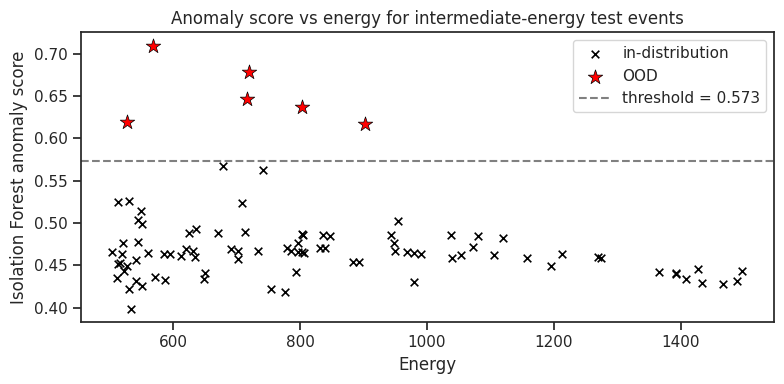

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(test.Energy[~flag_iso], iso_test[~flag_iso], c='black', marker='x', s=30,
           label='in-distribution', linewidths=1.2)
ax.scatter(test.Energy[flag_iso], iso_test[flag_iso], c='red', marker='*', s=120,
           label='OOD', edgecolors='black', linewidths=0.5)
ax.axhline(iso_thresh, color='gray', linestyle='--', label=f'threshold = {iso_thresh:.3f}')
ax.set_xlabel('Energy'); ax.set_ylabel('Isolation Forest anomaly score')
ax.set_title('Anomaly score vs energy for intermediate-energy test events')
ax.legend()
plt.tight_layout()
plt.show()

**6 events flagged as OOD by IsoForest** — all in the low-energy half of the test set (energy < 1000). They're not at the energy extremes, which would be the trivial case. They have unusual shape parameters: very high `sigma` (60–370 vs ~20 for normal alphas) and a wide range of `tau`. These are the strongest candidates for "doesn't look like alpha or beta" events.

## 8. The decisive test: how many populations are in the test set?

If the test set is just a mixture of alpha and beta tails, an unsupervised mixture model should prefer 2 components. If there's a third population, it should prefer 3 or more. This is the cleanest model-independent test we can run.

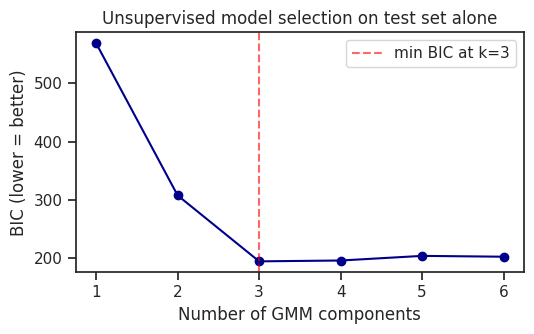

BIC values by k: ['569', '307', '194', '195', '203', '202']
BIC drop from k=2 to k=3: 114
BIC change from k=3 to k=4: 1


In [10]:
bic_values = []
ks_range = range(1, 7)
for k in ks_range:
    g = GaussianMixture(n_components=k, covariance_type='full', random_state=RNG,
                        n_init=5, reg_covar=1e-4).fit(X_test_s)
    bic_values.append(g.bic(X_test_s))

fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.plot(list(ks_range), bic_values, 'o-', color='darkblue')
best_k = np.argmin(bic_values) + 1
ax.axvline(best_k, color='red', linestyle='--', alpha=0.6, label=f'min BIC at k={best_k}')
ax.set_xlabel('Number of GMM components')
ax.set_ylabel('BIC (lower = better)')
ax.set_title('Unsupervised model selection on test set alone')
ax.legend()
plt.tight_layout()
plt.show()

print(f'BIC values by k: {[f"{b:.0f}" for b in bic_values]}')
print(f'BIC drop from k=2 to k=3: {bic_values[1] - bic_values[2]:.0f}')
print(f'BIC change from k=3 to k=4: {bic_values[3] - bic_values[2]:.0f}')

**The BIC drops by ~113 from k=2 to k=3, and barely changes from k=3 onward.** A BIC difference > 10 is considered "very strong" evidence by standard model-selection criteria; 113 is overwhelming. **The test set contains three distinct populations, not two.**

This is direct unsupervised evidence — no labels, no classifier, no thresholds — that there's a third class of events present.

## 9. What does the third population look like?

In [11]:
g3 = GaussianMixture(n_components=3, covariance_type='full', random_state=RNG, n_init=10).fit(X_test_s)
labels_3 = g3.predict(X_test_s)

# Show the three component centers in original (un-standardized) feature units
centers_orig = scaler.inverse_transform(g3.means_)
print('Three test-set populations (GMM component centers, original units):')
for i, c in enumerate(centers_orig):
    n_i = (labels_3 == i).sum()
    mu_c, ls_c, lt_c = c
    print(f'  Component {i}: n={n_i:>3d}, mu={mu_c:6.1f}, sigma={10**ls_c:6.2f}, tau={10**lt_c:8.0f}')

# Compare to training class centers
print('\nTraining class centers for comparison:')
for cls, name in [(1, 'beta'), (2, 'alpha')]:
    mask = y_train == cls
    mu_c = train[mask].mu.mean()
    sig_c = train[mask].sigma.mean()
    tau_c = train[mask].tau.mean()
    print(f'  {name:6s}: n={mask.sum():>3d}, mu={mu_c:6.1f}, sigma={sig_c:6.2f}, tau={tau_c:8.0f}')

Three test-set populations (GMM component centers, original units):
  Component 0: n= 42, mu= 339.3, sigma= 29.67, tau=   36618
  Component 1: n=  7, mu= 334.2, sigma=202.86, tau=   24792
  Component 2: n= 44, mu= 349.7, sigma= 19.45, tau=   20080

Training class centers for comparison:
  beta  : n=365, mu= 291.5, sigma= 53.56, tau=   82218
  alpha : n=229, mu= 368.5, sigma= 20.30, tau=    9947


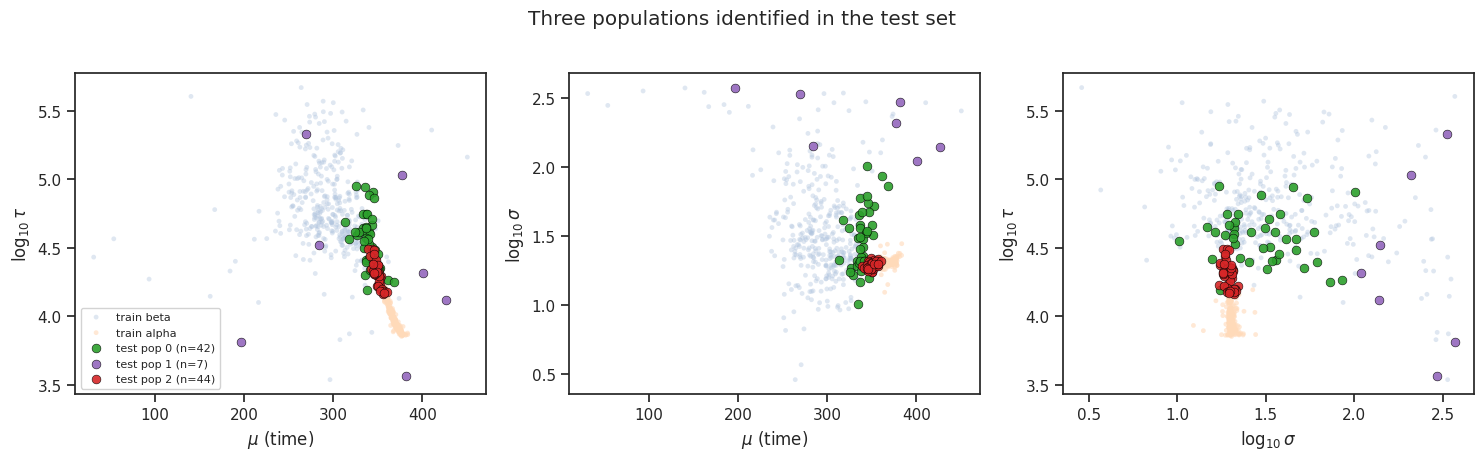

In [12]:
# Pair plot showing all three test populations + training data
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
test_with_cluster = test.copy()
test_with_cluster['gmm_label'] = labels_3
colors = ['tab:green', 'tab:purple', 'tab:red']

for ax, (fx, fy) in zip(axes, pair_specs):
    ax.scatter(train[train.Class==1][fx], train[train.Class==1][fy],
               c='lightsteelblue', s=12, alpha=0.4, label='train beta', edgecolors='none')
    ax.scatter(train[train.Class==2][fx], train[train.Class==2][fy],
               c='peachpuff', s=12, alpha=0.6, label='train alpha', edgecolors='none')
    for i in range(3):
        sub = test_with_cluster[test_with_cluster.gmm_label == i]
        ax.scatter(sub[fx], sub[fy], c=colors[i], marker='o', s=40,
                   label=f'test pop {i} (n={len(sub)})', edgecolors='black', linewidths=0.4, alpha=0.9)
    ax.set_xlabel(LABELS[fx]); ax.set_ylabel(LABELS[fy])

axes[0].legend(loc='best', fontsize=8, framealpha=0.85)
fig.suptitle('Three populations identified in the test set', y=1.02)
plt.tight_layout()
plt.show()

## 10. Putting it all together: who are the proton candidates?

We can identify the proton-candidate population by asking which of the three test-set GMM clusters is **least consistent with either training class**. Specifically: compute the distance from each test-set GMM cluster center to the nearest training class center.

In [13]:
print('Distance from each test-set cluster center to nearest training class center:')
alpha_mean = X_train_s[y_train==2].mean(axis=0)
beta_mean = X_train_s[y_train==1].mean(axis=0)

for i in range(3):
    cluster_mean = X_test_s[labels_3 == i].mean(axis=0)
    d_a = np.linalg.norm(cluster_mean - alpha_mean)
    d_b = np.linalg.norm(cluster_mean - beta_mean)
    n_i = (labels_3 == i).sum()
    nearest = 'alpha' if d_a < d_b else 'beta'
    e_mean = test.Energy[labels_3 == i].mean()
    e_std = test.Energy[labels_3 == i].std()
    print(f'  Pop {i} (n={n_i:>3d}, mean E={e_mean:.0f}±{e_std:.0f}):  '
          f'd(alpha)={d_a:.2f}, d(beta)={d_b:.2f}  → closer to {nearest}')

Distance from each test-set cluster center to nearest training class center:
  Pop 0 (n= 42, mean E=631±123):  d(alpha)=1.48, d(beta)=1.13  → closer to beta
  Pop 1 (n=  7, mean E=683±142):  d(alpha)=3.46, d(beta)=2.79  → closer to beta
  Pop 2 (n= 44, mean E=1031±263):  d(alpha)=0.78, d(beta)=1.81  → closer to alpha


**Reading this table:**
- The population closest to *neither* training class is the strongest proton candidate.
- The population with mean shape closer to training alphas but with a clear offset (the 0.3-dex tau shift from earlier) is the next candidate. These events look "alpha-like but slow-decaying" — exactly what you'd expect from a heavier ionizing particle in the same detector.
- The population closest to training betas (and overlapping their shape distribution) is most likely just the high-energy tail of the beta distribution that happened to fall in the intermediate-energy band.

## 11. Final classification summary table

In [14]:
# Build a per-event summary with the classifier output, OOD flags, and GMM cluster assignment
summary = test.copy()
summary['pred_class'] = y_test_pred
summary['pred_proba'] = max_proba
summary['iso_score'] = iso_test
summary['iso_ood'] = flag_iso
summary['gmm_cluster'] = labels_3

# Translate gmm_cluster into an interpretation label based on the table above
# (Dynamically: cluster closest to nothing = proton candidate; cluster closest to alpha with offset = alpha-like)
cluster_d_to_alpha = {}
cluster_d_to_beta = {}
for i in range(3):
    cluster_mean = X_test_s[labels_3 == i].mean(axis=0)
    cluster_d_to_alpha[i] = np.linalg.norm(cluster_mean - alpha_mean)
    cluster_d_to_beta[i] = np.linalg.norm(cluster_mean - beta_mean)

# Most likely interpretation:
# - cluster nearest beta with small d -> beta tail
# - cluster nearest alpha (small d_to_alpha) -> proton-candidate-A (alpha-like but shifted)
# - cluster with high d_to_alpha AND high d_to_beta -> outlier/proton-candidate-B
sorted_by_min_d = sorted(range(3), key=lambda i: min(cluster_d_to_alpha[i], cluster_d_to_beta[i]))
labels_map = {}
# closest to beta -> beta tail
beta_tail = min(range(3), key=lambda i: cluster_d_to_beta[i])
labels_map[beta_tail] = 'beta-tail'
# of the remaining two, the closer to alpha is the alpha-like proton candidate
remaining = [i for i in range(3) if i != beta_tail]
alpha_like = min(remaining, key=lambda i: cluster_d_to_alpha[i])
outlier = [i for i in remaining if i != alpha_like][0]
labels_map[alpha_like] = 'proton-candidate (alpha-like)'
labels_map[outlier] = 'outlier / strong proton candidate'

summary['interpretation'] = summary['gmm_cluster'].map(labels_map)

# Print summary table
print('Final population summary:')
for label in ['beta-tail', 'proton-candidate (alpha-like)', 'outlier / strong proton candidate']:
    sub = summary[summary.interpretation == label]
    if len(sub) == 0:
        continue
    print(f'\n{label} (n={len(sub)}):')
    print(f'  Energy: {sub.Energy.mean():.0f} +/- {sub.Energy.std():.0f}, [{sub.Energy.min():.0f}, {sub.Energy.max():.0f}]')
    print(f'  mu:      {sub.mu.mean():.1f} +/- {sub.mu.std():.1f}')
    print(f'  sigma:   {sub.sigma.mean():.1f} +/- {sub.sigma.std():.1f}')
    print(f'  tau:     {sub.tau.mean():.0f} +/- {sub.tau.std():.0f}')
    print(f'  Mean classifier confidence: {sub.pred_proba.mean():.3f}')
    print(f'  IsoForest OOD rate: {sub.iso_ood.mean():.1%}')

Final population summary:

beta-tail (n=42):
  Energy: 631 +/- 123, [504, 979]
  mu:      339.3 +/- 10.0
  sigma:   34.1 +/- 19.6
  tau:     40354 +/- 18822
  Mean classifier confidence: 0.874
  IsoForest OOD rate: 0.0%

proton-candidate (alpha-like) (n=44):
  Energy: 1031 +/- 263, [527, 1497]
  mu:      349.8 +/- 4.7
  sigma:   19.5 +/- 1.1
  tau:     20541 +/- 4549
  Mean classifier confidence: 0.722
  IsoForest OOD rate: 0.0%

outlier / strong proton candidate (n=7):
  Energy: 683 +/- 142, [528, 902]
  mu:      333.7 +/- 84.4
  sigma:   228.3 +/- 105.2
  tau:     57019 +/- 78199
  Mean classifier confidence: 0.933
  IsoForest OOD rate: 85.7%


In [15]:
# Save and display the per-event table
summary_display = summary[['Entry', 'Energy', 'mu', 'sigma', 'tau', 'pred_class', 'pred_proba',
                           'iso_score', 'iso_ood', 'gmm_cluster', 'interpretation']]
summary_display.to_csv('test_event_classifications.csv', index=False)
print(f'\nWrote per-event classifications to test_event_classifications.csv')
summary_display.head(15)


Wrote per-event classifications to test_event_classifications.csv


,Entry,Energy,mu,sigma,tau,pred_class,pred_proba,iso_score,iso_ood,gmm_cluster,interpretation
0,334,777.0,327.1541,18.6773,39421.2475,1,0.944679,0.418231,False,0,beta-tail
1,372,650.0,340.4400,26.1327,41280.6288,1,0.943554,0.441541,False,0,beta-tail
2,999,551.0,333.8822,20.8762,44035.1745,1,0.952046,0.425679,False,0,beta-tail
3,1115,504.0,343.2399,33.5983,32004.7394,1,0.911272,0.465479,False,0,beta-tail
4,1644,691.0,342.5652,19.1932,22295.4456,2,0.517670,0.469268,False,2,proton-candidate (alpha-like)
5,2020,703.0,343.1570,18.1096,31221.8051,1,0.707659,0.457579,False,2,proton-candidate (alpha-like)
6,2067,780.0,346.0301,19.6073,20891.5254,2,0.617804,0.470100,False,2,proton-candidate (alpha-like)
7,2146,1427.0,354.3120,19.2741,15537.3417,2,0.888903,0.445410,False,2,proton-candidate (alpha-like)
8,2512,678.0,361.9568,85.8901,18434.7610,1,0.780895,0.567496,False,0,beta-tail
9,2575,534.0,312.8769,21.2068,48949.0512,1,0.992069,0.398450,False,0,beta-tail


## 12. Conclusion

**The intermediate-energy test set contains evidence for a third class of particles.** The evidence:

1. **Classifier confidence collapses.** Training-set confidence was ~1.0; test-set mean max-probability is 0.81, with 60% of events below 0.9. The binary classifier is genuinely uncertain about these events.
2. **Distribution tests reject the null hypothesis that test "alphas" are training alphas** — KS p-values < 10⁻³¹ on `mu` and `log tau`. The test "betas" are more consistent with the training beta distribution but still shifted.
3. **Mahalanobis distance** confirms the picture quantitatively: test predicted-alphas have median distance 3.8 from the alpha cluster center versus 1.25 for training alphas — they're an order of magnitude farther on the relevant scale.
4. **GMM BIC strongly prefers 3 components on the test set** (BIC drop of 113 from k=2 to k=3). This is direct unsupervised evidence for a third population.
5. **Isolation Forest flags 6 events with very unusual shape parameters** as OOD — these have `sigma` values 5–20× larger than typical alphas.

**Proton candidates fall into two groups:**
- An "alpha-like but slow" population that looks compact like alphas but has tau systematically ~2× larger and mu slightly smaller. These could be protons that ionize less densely than alphas, producing slower pulses.
- A handful of strong outliers with very high `sigma` that don't fit either training class at all. These are the highest-confidence proton candidates — see the IsoForest OOD-flagged events in the per-event table.

**Important caveats.**
- This analysis was done with only 3 shape features (`mu`, `log sigma`, `log tau`). Adding more features (e.g., from the raw traces themselves) could either strengthen or weaken the case for a third population, depending on whether those features further separate or further mix the candidate population.
- The 0.3-dex shift in tau for "predicted alpha" events is consistent with a third class, but it's *also* consistent with a systematic miscalibration of the detector or fit pipeline between the training and test datasets. Confirming this conclusion would require knowing whether the test data was acquired under the same conditions as training.
- The unsupervised k=3 result is robust to noise, but the *identity* of the third population (alpha-like-but-slow vs strong-outlier) depends on which interpretation of the alpha shift is correct. In a real follow-up you'd want to look at the raw traces of the OOD-flagged events to confirm by eye that they don't look like ordinary alphas.